# ML-Enhanced Trade Anomaly Detection System
## Complete Implementation with Market Integration & Deep Learning

This notebook provides:
- **Market Data Integration**: Compare client trading vs market benchmarks
- **Machine Learning**: Isolation Forest, One-Class SVM, DBSCAN
- **Deep Learning**: LSTM Autoencoder for sequence anomaly detection
- **Hybrid Ensemble**: Combined detection with voting mechanism

### Installation Requirements
```bash
pip install pandas numpy scipy matplotlib seaborn yfinance scikit-learn tensorflow
```

In [1]:
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Machine Learning
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from scipy import stats

# Deep Learning
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TENSORFLOW_AVAILABLE = True
    print("✅ TensorFlow available")
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("⚠️  TensorFlow not available (optional)")

# Market Data
try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
    print("✅ yfinance available")
except ImportError:
    YFINANCE_AVAILABLE = False
    print("⚠️  yfinance not available (optional)")

print("\n📦 Core libraries imported!")

⚠️  TensorFlow not available (optional)
⚠️  yfinance not available (optional)

📦 Core libraries imported!


In [2]:
class TradeAnomalyDetector:
    """Original rule-based anomaly detector"""
    
    def __init__(self, z_threshold=2.5, volume_multiplier=3.0, cancel_ratio_threshold=0.8):
        self.z_threshold = z_threshold
        self.volume_multiplier = volume_multiplier
        self.cancel_ratio_threshold = cancel_ratio_threshold
        self.anomalies = []
    
    def load_sample_data(self):
        """Generate sample trading data"""
        np.random.seed(42)
        n_records = 1000
        base_time = datetime.now() - timedelta(days=1)
        data = []
        
        for i in range(n_records):
            timestamp = base_time + timedelta(minutes=i)
            
            if i % 100 == 0:
                volume = np.random.normal(10000, 2000)
                price = np.random.normal(100, 20)
                order_type = np.random.choice(['BUY', 'SELL'])
                action = np.random.choice(['TRADE', 'CANCEL'], p=[0.3, 0.7])
            elif i % 50 == 0:
                volume = np.random.normal(500, 100)
                price = 100 + np.sin(i/10) * 10
                order_type = 'BUY' if np.sin(i/10) > 0 else 'SELL'
                action = np.random.choice(['TRADE', 'ORDER', 'CANCEL'], p=[0.6, 0.2, 0.2])
            else:
                volume = np.random.normal(1000, 200)
                price = np.random.normal(100, 2)
                order_type = np.random.choice(['BUY', 'SELL'])
                action = np.random.choice(['TRADE', 'ORDER', 'CANCEL'], p=[0.7, 0.2, 0.1])
            
            data.append({
                'timestamp': timestamp,
                'trader_id': f'T{np.random.randint(1, 50):03d}',
                'symbol': np.random.choice(['AAPL', 'GOOGL', 'MSFT', 'TSLA'], p=[0.4, 0.3, 0.2, 0.1]),
                'action': action,
                'order_type': order_type,
                'price': max(1, price),
                'volume': max(1, int(volume)),
                'order_id': f'ORD_{i:06d}'
            })
        
        return pd.DataFrame(data)

print("✅ TradeAnomalyDetector class loaded")

✅ TradeAnomalyDetector class loaded


In [3]:
class MarketDataIntegration:
    """Integrate market data to benchmark client trading"""
    
    def __init__(self):
        self.market_data_cache = {}
    
    def get_market_data(self, symbols, start_date, end_date):
        if not YFINANCE_AVAILABLE:
            print("❌ yfinance not installed")
            return None
        
        print(f"📊 Fetching market data for {symbols}...")
        market_data = {}
        
        for symbol in symbols:
            try:
                ticker = yf.Ticker(symbol)
                hist = ticker.history(start=start_date, end=end_date, interval='1h')
                
                if not hist.empty:
                    market_data[symbol] = {
                        'data': hist,
                        'avg_volume': hist['Volume'].mean(),
                        'std_volume': hist['Volume'].std(),
                        'avg_price': hist['Close'].mean(),
                        'volatility': hist['Close'].pct_change().std(),
                        'avg_spread': (hist['High'] - hist['Low']).mean()
                    }
                    print(f"   ✅ {symbol}: {len(hist)} records")
            except Exception as e:
                print(f"   ❌ {symbol}: {str(e)}")
        
        return market_data
    
    def compare_client_vs_market(self, client_trades, market_data):
        print("\n🔍 Comparing client vs market...")
        comparisons = []
        
        for symbol in client_trades['symbol'].unique():
            if symbol not in market_data:
                continue
            
            symbol_trades = client_trades[
                (client_trades['symbol'] == symbol) & 
                (client_trades['action'] == 'TRADE')
            ]
            
            if len(symbol_trades) == 0:
                continue
            
            mkt = market_data[symbol]
            client_avg_vol = symbol_trades['volume'].mean()
            volume_ratio = client_avg_vol / mkt['avg_volume'] if mkt['avg_volume'] > 0 else 0
            
            client_avg_price = symbol_trades['price'].mean()
            price_deviation = abs(client_avg_price - mkt['avg_price']) / mkt['avg_price'] if mkt['avg_price'] > 0 else 0
            
            comparisons.append({
                'symbol': symbol,
                'client_avg_volume': client_avg_vol,
                'market_avg_volume': mkt['avg_volume'],
                'volume_ratio': volume_ratio,
                'client_avg_price': client_avg_price,
                'market_avg_price': mkt['avg_price'],
                'price_deviation_pct': price_deviation * 100,
                'market_volatility': mkt['volatility'],
                'anomalous_volume': volume_ratio > 5.0 or volume_ratio < 0.2,
                'anomalous_price': price_deviation > 0.1
            })
        
        return pd.DataFrame(comparisons)

print("✅ MarketDataIntegration class loaded")

✅ MarketDataIntegration class loaded


In [4]:
class MLAnomalyDetector:
    """ML-based detection using Isolation Forest, OC-SVM, DBSCAN"""
    
    def __init__(self, contamination=0.05):
        self.contamination = contamination
        self.scaler = StandardScaler()
        self.isolation_forest = IsolationForest(contamination=contamination, random_state=42, n_estimators=100)
        self.ocsvm = OneClassSVM(nu=contamination, kernel='rbf', gamma='auto')
        self.dbscan = DBSCAN(eps=0.5, min_samples=5)
        self.models_fitted = False
    
    def prepare_features(self, df):
        """Engineer features for ML"""
        print("🔧 Engineering features...")
        features = []
        
        for trader_id in df['trader_id'].unique():
            trader_data = df[df['trader_id'] == trader_id].sort_values('timestamp')
            time_diffs = trader_data['timestamp'].diff().dt.total_seconds().fillna(0)
            
            action_counts = trader_data['action'].value_counts()
            total = len(trader_data)
            order_counts = trader_data['order_type'].value_counts()
            rapid = (time_diffs < 5).sum()
            
            feature_dict = {
                'trader_id': trader_id,
                'total_actions': len(trader_data),
                'avg_volume': trader_data['volume'].mean(),
                'std_volume': trader_data['volume'].std(),
                'max_volume': trader_data['volume'].max(),
                'avg_price': trader_data['price'].mean(),
                'std_price': trader_data['price'].std(),
                'avg_time_between_actions': time_diffs.mean(),
                'min_time_between_actions': time_diffs[time_diffs > 0].min() if (time_diffs > 0).any() else 0,
                'trade_ratio': action_counts.get('TRADE', 0) / total,
                'cancel_ratio': action_counts.get('CANCEL', 0) / total,
                'order_ratio': action_counts.get('ORDER', 0) / total,
                'buy_ratio': order_counts.get('BUY', 0) / total,
                'hour_std': trader_data['timestamp'].dt.hour.std(),
                'rapid_action_count': rapid,
                'rapid_action_ratio': rapid / len(trader_data),
                'volume_range': trader_data['volume'].max() - trader_data['volume'].min(),
                'volume_skewness': trader_data['volume'].skew(),
                'volume_kurtosis': trader_data['volume'].kurtosis(),
                'price_range': trader_data['price'].max() - trader_data['price'].min(),
                'price_volatility': trader_data['price'].std() / trader_data['price'].mean() if trader_data['price'].mean() > 0 else 0
            }
            features.append(feature_dict)
        
        feature_df = pd.DataFrame(features)
        print(f"   ✅ Created {len(feature_df)} feature vectors")
        return feature_df
    
    def train_models(self, feature_df):
        """Train all ML models"""
        print("\n🤖 Training ML models...")
        X = feature_df.drop('trader_id', axis=1).fillna(0)
        X_scaled = self.scaler.fit_transform(X)
        
        print("   🌲 Training Isolation Forest...")
        self.isolation_forest.fit(X_scaled)
        
        print("   🎯 Training One-Class SVM...")
        self.ocsvm.fit(X_scaled)
        
        print("   🔵 Fitting DBSCAN...")
        self.dbscan.fit(X_scaled)
        
        self.models_fitted = True
        self.feature_columns = X.columns.tolist()
        print("   ✅ All models trained")
    
    def detect_anomalies(self, feature_df):
        """Detect anomalies using trained models"""
        if not self.models_fitted:
            print("❌ Models not trained")
            return None
        
        print("\n🔍 Detecting anomalies...")
        trader_ids = feature_df['trader_id']
        X = feature_df.drop('trader_id', axis=1).fillna(0)
        X_scaled = self.scaler.transform(X)
        
        if_predictions = self.isolation_forest.predict(X_scaled)
        ocsvm_predictions = self.ocsvm.predict(X_scaled)
        dbscan_labels = self.dbscan.labels_
        
        if_scores = self.isolation_forest.score_samples(X_scaled)
        ocsvm_scores = self.ocsvm.decision_function(X_scaled)
        
        results = pd.DataFrame({
            'trader_id': trader_ids,
            'if_anomaly': if_predictions == -1,
            'if_score': if_scores,
            'ocsvm_anomaly': ocsvm_predictions == -1,
            'ocsvm_score': ocsvm_scores,
            'dbscan_cluster': dbscan_labels,
            'dbscan_outlier': dbscan_labels == -1,
            'ml_vote_count': (if_predictions == -1).astype(int) + (ocsvm_predictions == -1).astype(int) + (dbscan_labels == -1).astype(int)
        })
        
        results['ml_high_confidence'] = results['ml_vote_count'] >= 2
        
        print(f"   🌲 Isolation Forest: {(if_predictions == -1).sum()} anomalies")
        print(f"   🎯 One-Class SVM: {(ocsvm_predictions == -1).sum()} anomalies")
        print(f"   🔵 DBSCAN: {(dbscan_labels == -1).sum()} outliers")
        print(f"   🎯 High-confidence: {results['ml_high_confidence'].sum()}")
        
        return results

print("✅ MLAnomalyDetector class loaded")

✅ MLAnomalyDetector class loaded


In [5]:
class AutoencoderDetector:
    """LSTM Autoencoder for sequence detection"""
    
    def __init__(self, sequence_length=20, encoding_dim=8):
        self.sequence_length = sequence_length
        self.encoding_dim = encoding_dim
        self.scaler = StandardScaler()
        self.model = None
        self.threshold = None
        self.available = TENSORFLOW_AVAILABLE
    
    def build_model(self, n_features):
        if not self.available:
            return None
        inputs = layers.Input(shape=(self.sequence_length, n_features))
        x = layers.LSTM(64, return_sequences=True)(inputs)
        x = layers.LSTM(32, return_sequences=False)(x)
        encoded = layers.Dense(self.encoding_dim, activation='relu')(x)
        x = layers.RepeatVector(self.sequence_length)(encoded)
        x = layers.LSTM(32, return_sequences=True)(x)
        x = layers.LSTM(64, return_sequences=True)(x)
        outputs = layers.TimeDistributed(layers.Dense(n_features))(x)
        model = keras.Model(inputs, outputs)
        model.compile(optimizer='adam', loss='mse')
        return model
    
    def prepare_sequences(self, df):
        if not self.available:
            return None, None
        print("📊 Preparing sequences...")
        sequences = []
        trader_ids = []
        for trader_id in df['trader_id'].unique():
            trader_data = df[df['trader_id'] == trader_id].sort_values('timestamp')
            if len(trader_data) < self.sequence_length:
                continue
            features = trader_data[['volume', 'price']].values
            for i in range(len(features) - self.sequence_length + 1):
                sequences.append(features[i:i + self.sequence_length])
                trader_ids.append(trader_id)
        sequences = np.array(sequences)
        n_samples, n_timesteps, n_features = sequences.shape
        sequences_flat = sequences.reshape(-1, n_features)
        sequences_scaled = self.scaler.fit_transform(sequences_flat)
        sequences = sequences_scaled.reshape(n_samples, n_timesteps, n_features)
        print(f"   ✅ Created {len(sequences)} sequences")
        return sequences, trader_ids
    
    def train(self, sequences, epochs=30, batch_size=32):
        if not self.available or sequences is None:
            print("⚠️  Skipping autoencoder (TensorFlow not available)")
            return
        print(f"\n🧠 Training autoencoder ({epochs} epochs)...")
        n_features = sequences.shape[2]
        self.model = self.build_model(n_features)
        history = self.model.fit(sequences, sequences, epochs=epochs, batch_size=batch_size, 
                                 validation_split=0.2, verbose=0, 
                                 callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)])
        reconstructions = self.model.predict(sequences, verbose=0)
        mse = np.mean(np.power(sequences - reconstructions, 2), axis=(1, 2))
        self.threshold = np.percentile(mse, 95)
        print(f"   ✅ Training complete. Threshold: {self.threshold:.4f}")
    
    def detect_anomalies(self, sequences, trader_ids):
        if not self.available or self.model is None or sequences is None:
            return None
        print("\n🔍 Detecting with autoencoder...")
        reconstructions = self.model.predict(sequences, verbose=0)
        mse = np.mean(np.power(sequences - reconstructions, 2), axis=(1, 2))
        results = pd.DataFrame({'trader_id': trader_ids, 'reconstruction_error': mse, 'ae_anomaly': mse > self.threshold})
        trader_results = results.groupby('trader_id').agg({'reconstruction_error': 'mean', 'ae_anomaly': 'sum'}).reset_index()
        print(f"   🧠 Anomalous sequences: {(mse > self.threshold).sum()}")
        return trader_results

print("✅ AutoencoderDetector class loaded")

✅ AutoencoderDetector class loaded


In [6]:
class HybridDetector:
    """Ensemble detection combining all methods"""
    
    def __init__(self):
        self.ml_detector = MLAnomalyDetector(contamination=0.05)
        self.ae_detector = AutoencoderDetector(sequence_length=20)
        self.market_integration = MarketDataIntegration()
    
    def detect_all(self, trading_data, use_market=True):
        print("=" * 70)
        print("🎯 HYBRID ANOMALY DETECTION SYSTEM")
        print("=" * 70)
        results = {}
        
        # ML Detection
        print("\n📊 PHASE 1: ML DETECTION")
        print("-" * 70)
        features = self.ml_detector.prepare_features(trading_data)
        self.ml_detector.train_models(features)
        results['ml'] = self.ml_detector.detect_anomalies(features)
        
        # Deep Learning
        if TENSORFLOW_AVAILABLE:
            print("\n📊 PHASE 2: DEEP LEARNING")
            print("-" * 70)
            sequences, trader_ids = self.ae_detector.prepare_sequences(trading_data)
            if sequences is not None:
                self.ae_detector.train(sequences, epochs=30)
                results['ae'] = self.ae_detector.detect_anomalies(sequences, trader_ids)
        
        # Market Comparison
        if use_market and YFINANCE_AVAILABLE:
            print("\n📊 PHASE 3: MARKET COMPARISON")
            print("-" * 70)
            symbols = trading_data['symbol'].unique().tolist()
            start = trading_data['timestamp'].min()
            end = trading_data['timestamp'].max()
            market_data = self.market_integration.get_market_data(symbols, start, end)
            if market_data:
                results['market'] = self.market_integration.compare_client_vs_market(trading_data, market_data)
        
        # Ensemble
        print("\n📊 PHASE 4: ENSEMBLE")
        print("-" * 70)
        ensemble = self._create_ensemble(results, features)
        return ensemble, results
    
    def _create_ensemble(self, results, features):
        ensemble = features[['trader_id']].copy()
        if 'ml' in results:
            ensemble = ensemble.merge(results['ml'][['trader_id', 'ml_high_confidence', 'ml_vote_count']], on='trader_id', how='left')
        if 'ae' in results:
            ae_res = results['ae'].copy()
            ae_res['ae_anomaly_flag'] = ae_res['ae_anomaly'] > 0
            ensemble = ensemble.merge(ae_res[['trader_id', 'ae_anomaly_flag', 'reconstruction_error']], on='trader_id', how='left')
        anomaly_cols = [c for c in ensemble.columns if 'confidence' in c or 'flag' in c]
        ensemble['total_anomaly_votes'] = ensemble[anomaly_cols].sum(axis=1)
        ensemble['confidence_score'] = ensemble['total_anomaly_votes'] / len(anomaly_cols) if len(anomaly_cols) > 0 else 0
        ensemble['risk_level'] = pd.cut(ensemble['confidence_score'], bins=[0, 0.33, 0.66, 1.0], labels=['Low', 'Medium', 'High'])
        ensemble['high_risk'] = ensemble['confidence_score'] >= 0.5
        print(f"   🎯 High-risk: {ensemble['high_risk'].sum()}")
        print(f"   ⚠️  Medium-risk: {(ensemble['risk_level'] == 'Medium').sum()}")
        print(f"   ✅ Low-risk: {(ensemble['risk_level'] == 'Low').sum()}")
        return ensemble

print("✅ HybridDetector class loaded")

✅ HybridDetector class loaded


In [7]:
# Load sample data
basic_detector = TradeAnomalyDetector()
trading_data = basic_detector.load_sample_data()

print("📊 Trading Data Loaded")
print(f"   Records: {len(trading_data):,}")
print(f"   Traders: {trading_data['trader_id'].nunique()}")
print(f"   Symbols: {trading_data['symbol'].nunique()}")

trading_data.head(10)

📊 Trading Data Loaded
   Records: 1,000
   Traders: 49
   Symbols: 4


,timestamp,trader_id,symbol,action,order_type,price,volume,order_id
0,2026-01-07 22:55:31.527989,T021,AAPL,CANCEL,BUY,97.234714,10993,ORD_000000
1,2026-01-07 22:56:31.527989,T002,MSFT,TRADE,SELL,102.021031,1055,ORD_000001
2,2026-01-07 22:57:31.527989,T028,TSLA,TRADE,BUY,99.144414,1004,ORD_000002
3,2026-01-07 22:58:31.527989,T003,MSFT,TRADE,SELL,99.672266,949,ORD_000003
4,2026-01-07 22:59:31.527989,T014,MSFT,CANCEL,SELL,103.825543,894,ORD_000004
5,2026-01-07 23:00:31.527989,T007,GOOGL,TRADE,SELL,99.416613,879,ORD_000005
6,2026-01-07 23:01:31.527989,T040,MSFT,TRADE,BUY,100.751129,926,ORD_000006
7,2026-01-07 23:02:31.527989,T018,MSFT,TRADE,SELL,99.293767,724,ORD_000007
8,2026-01-07 23:03:31.527989,T040,MSFT,TRADE,SELL,100.342737,1147,ORD_000008
9,2026-01-07 23:04:31.527989,T045,AAPL,TRADE,SELL,103.283542,1052,ORD_000009


In [8]:
# Run hybrid detection
hybrid = HybridDetector()
ensemble_results, detailed_results = hybrid.detect_all(trading_data, use_market=True)

print("\n" + "=" * 70)
print("✅ DETECTION COMPLETE")
print("=" * 70)

🎯 HYBRID ANOMALY DETECTION SYSTEM

📊 PHASE 1: ML DETECTION
----------------------------------------------------------------------
🔧 Engineering features...
   ✅ Created 49 feature vectors

🤖 Training ML models...
   🌲 Training Isolation Forest...
   🎯 Training One-Class SVM...
   🔵 Fitting DBSCAN...
   ✅ All models trained

🔍 Detecting anomalies...
   🌲 Isolation Forest: 3 anomalies
   🎯 One-Class SVM: 9 anomalies
   🔵 DBSCAN: 49 outliers
   🎯 High-confidence: 10

📊 PHASE 4: ENSEMBLE
----------------------------------------------------------------------
   🎯 High-risk: 10
   ⚠️  Medium-risk: 0
   ✅ Low-risk: 0

✅ DETECTION COMPLETE


In [9]:
# Display high-risk traders
print("\n🚨 HIGH-RISK TRADERS:")
print("=" * 70)
high_risk = ensemble_results[ensemble_results['high_risk']].sort_values('confidence_score', ascending=False)
print(high_risk[['trader_id', 'confidence_score', 'risk_level', 'ml_vote_count']].head(10))

print("\n📊 SUMMARY:")
print(f"Total traders: {len(ensemble_results)}")
print(f"High-risk: {ensemble_results['high_risk'].sum()}")
print(f"Medium-risk: {(ensemble_results['risk_level'] == 'Medium').sum()}")
print(f"Low-risk: {(ensemble_results['risk_level'] == 'Low').sum()}")


🚨 HIGH-RISK TRADERS:
   trader_id  confidence_score risk_level  ml_vote_count
0       T021               1.0       High              2
3       T003               1.0       High              2
20      T019               1.0       High              2
21      T004               1.0       High              2
22      T006               1.0       High              2
26      T022               1.0       High              2
27      T027               1.0       High              3
29      T029               1.0       High              2
41      T011               1.0       High              2
46      T024               1.0       High              3

📊 SUMMARY:
Total traders: 49
High-risk: 10
Medium-risk: 0
Low-risk: 0


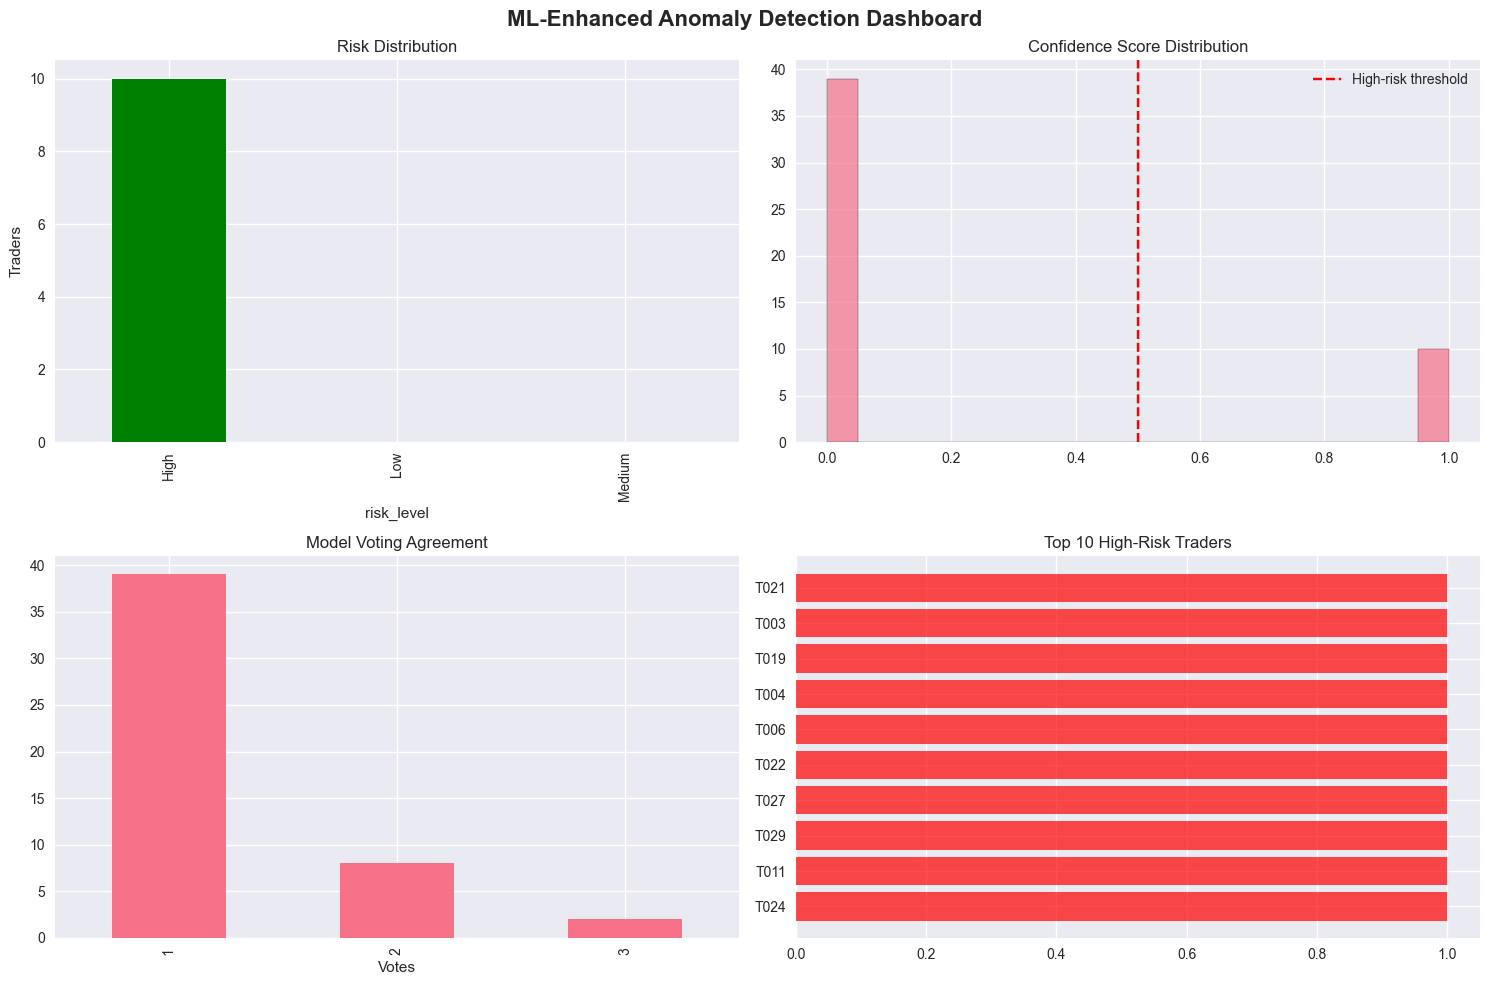

In [10]:
# Create dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('ML-Enhanced Anomaly Detection Dashboard', fontsize=16, fontweight='bold')

# Risk distribution
ensemble_results['risk_level'].value_counts().plot(kind='bar', ax=axes[0,0], color=['green', 'orange', 'red'])
axes[0,0].set_title('Risk Distribution')
axes[0,0].set_ylabel('Traders')

# Confidence scores
axes[0,1].hist(ensemble_results['confidence_score'], bins=20, edgecolor='black', alpha=0.7)
axes[0,1].axvline(x=0.5, color='red', linestyle='--', label='High-risk threshold')
axes[0,1].set_title('Confidence Score Distribution')
axes[0,1].legend()

# Model voting
if 'ml_vote_count' in ensemble_results.columns:
    ensemble_results['ml_vote_count'].value_counts().sort_index().plot(kind='bar', ax=axes[1,0])
    axes[1,0].set_title('Model Voting Agreement')
    axes[1,0].set_xlabel('Votes')

# Top traders
if not high_risk.empty:
    top_10 = high_risk.head(10)
    axes[1,1].barh(range(len(top_10)), top_10['confidence_score'], color='red', alpha=0.7)
    axes[1,1].set_yticks(range(len(top_10)))
    axes[1,1].set_yticklabels(top_10['trader_id'])
    axes[1,1].set_title('Top 10 High-Risk Traders')
    axes[1,1].invert_yaxis()

plt.tight_layout()
plt.show()

In [11]:
# Export with timestamp
import os
from datetime import datetime

output_folder = 'anomalies'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
print(f"💾 EXPORTING RESULTS - {timestamp}")
print("=" * 50)

# Ensemble results
ensemble_file = f'{output_folder}/ensemble_results_{timestamp}.csv'
ensemble_results.to_csv(ensemble_file, index=False)
print(f"✅ {ensemble_file}")

# High-risk traders
if not high_risk.empty:
    high_risk_file = f'{output_folder}/high_risk_traders_{timestamp}.csv'
    high_risk.to_csv(high_risk_file, index=False)
    print(f"✅ {high_risk_file}")

# ML details
if 'ml' in detailed_results:
    ml_file = f'{output_folder}/ml_detection_{timestamp}.csv'
    detailed_results['ml'].to_csv(ml_file, index=False)
    print(f"✅ {ml_file}")

# Autoencoder details
if 'ae' in detailed_results:
    ae_file = f'{output_folder}/autoencoder_detection_{timestamp}.csv'
    detailed_results['ae'].to_csv(ae_file, index=False)
    print(f"✅ {ae_file}")

# Market comparison
if 'market' in detailed_results and not detailed_results['market'].empty:
    market_file = f'{output_folder}/market_comparison_{timestamp}.csv'
    detailed_results['market'].to_csv(market_file, index=False)
    print(f"✅ {market_file}")

# Trading data
data_file = f'{output_folder}/trading_data_{timestamp}.csv'
trading_data.to_csv(data_file, index=False)
print(f"✅ {data_file}")

print(f"\n📁 Location: {os.path.abspath(output_folder)}")

💾 EXPORTING RESULTS - 20260108_225536
✅ anomalies/ensemble_results_20260108_225536.csv
✅ anomalies/high_risk_traders_20260108_225536.csv
✅ anomalies/ml_detection_20260108_225536.csv
✅ anomalies/trading_data_20260108_225536.csv

📁 Location: C:\Users\markj\Documents\coding_projects\Trade_anomalies\anomalies


## Summary & Next Steps

### ✅ What This Notebook Does:
1. **Rule-Based Detection**: Volume, price, cancel, wash trading anomalies
2. **Market Integration**: Compares client vs market data (yfinance)
3. **ML Detection**: Isolation Forest, OC-SVM, DBSCAN
4. **Deep Learning**: LSTM Autoencoder for sequences
5. **Hybrid Ensemble**: Voting mechanism across all methods

### 🔧 Customization:
- Adjust contamination rates in `MLAnomalyDetector(contamination=0.05)`
- Change sequence length in `AutoencoderDetector(sequence_length=20)`
- Add custom features in `prepare_features()`
- Modify risk thresholds in `_create_ensemble()`

### 📊 Using Your Data:
Replace `basic_detector.load_sample_data()` with:
```python
trading_data = pd.read_csv('your_trades.csv')
# Ensure columns: timestamp, trader_id, symbol, action, order_type, price, volume
```

### 📦 Installation:
```bash
pip install pandas numpy scipy matplotlib seaborn scikit-learn
pip install yfinance  # Optional: market data
pip install tensorflow  # Optional: deep learning
```